In [48]:
import numpy as np 
import xarray as xr
import rioxarray as rio
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
import seaborn as sns
sns.set_theme()

import s3fs
import fsspec

In [4]:
base_url = f's3://noaa-nws-aorc-v1-1-1km'

s3_out = s3fs.S3FileSystem(anon=True)
fileset = [s3fs.S3Map(
                root=f"s3://{base_url}/{yr}.zarr", s3=s3_out, check=False
            ) for yr in (2020, 2021)]
full_ds = xr.open_mfdataset(fileset, engine='zarr')

In [6]:
data_dir = '../data/'# on local machine 
mcs_aoi = gpd.read_file(data_dir + 'mores_creek.shp')
mcs_aoi

,id,geometry
0,1,"POLYGON ((-115.6739 43.98328, -115.67315 43.98..."


In [91]:
mcs_lowman_05208_dates = ['200131_200213',
 '200131_200220',
 '200131_200311',
 '200131_210203',
 '200131_210210',
 '200131_210303',
 '200131_210310',
 '200131_210316',
 '200131_210322',
 '200213_200220',
 '200213_200311',
 '200213_210203',
 '200213_210210',
 '200213_210303',
 '200213_210310',
 '200213_210316',
 '200213_210322',
 '200220_200311',
 '200220_210203',
 '200220_210210',
 '200220_210303',
 '200220_210310',
 '200220_210316',
 '200220_210322',
 '200311_210203',
 '200311_210210',
 '200311_210303',
 '200311_210310',
 '200311_210316',
 '200311_210322',
 '210203_210210',
 '210203_210303',
 '210203_210310',
 '210203_210316',
 '210203_210322',
 '210210_210303',
 '210210_210310',
 '210210_210316',
 '210210_210322',
 '210303_210310',
 '210303_210316',
 '210303_210322',
 '210310_210316',
 '210310_210322',
 '210316_210322']

split_dates = [(part[0], part[1]) for part in [d.split('_') for d in mcs_lowman_05208_dates]]
# get all unique individual dates
unique_dates = set([date for pair in split_dates for date in pair])
# convert to datetime objects
mcs_dates = [datetime.strptime(date, '%y%m%d') for date in unique_dates]
print(mcs_dates)

[datetime.datetime(2021, 2, 10, 0, 0), datetime.datetime(2020, 2, 20, 0, 0), datetime.datetime(2021, 3, 16, 0, 0), datetime.datetime(2020, 1, 31, 0, 0), datetime.datetime(2020, 3, 11, 0, 0), datetime.datetime(2021, 3, 10, 0, 0), datetime.datetime(2021, 3, 3, 0, 0), datetime.datetime(2021, 3, 22, 0, 0), datetime.datetime(2021, 2, 3, 0, 0), datetime.datetime(2020, 2, 13, 0, 0)]


In [10]:
minlon, minlat, maxlon, maxlat = mcs_aoi.total_bounds
full_ds = full_ds.rio.clip_box(minx=minlon,
                                    miny=minlat,
                                    maxx=maxlon,
                                    maxy=maxlat)
full_ds

<xarray.Dataset> Size: 146MB
Dimensions:              (latitude: 10, longitude: 13, time: 17544)
Coordinates:
  * latitude             (latitude) float64 80B 43.91 43.92 ... 43.97 43.98
  * longitude            (longitude) float64 104B -115.7 -115.7 ... -115.6
  * time                 (time) datetime64[ns] 140kB 2020-01-01 ... 2021-12-3...
    spatial_ref          int64 8B 0
Data variables:
    APCP_surface         (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    DLWRF_surface        (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    DSWRF_surface        (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    PRES_surface         (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    SPFH_2maboveground   (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    TMP_2maboveground    (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    UGRD_10maboveground  (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    VGRD_10maboveground  (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>

In [28]:
# calculate averages over the AOI
ds_means = full_ds.mean(dim=['latitude', 'longitude'])

# do a median filter
ds_means = ds_means.rolling(time=3, center=True).median().compute()
ds_means

<xarray.Dataset> Size: 1MB
Dimensions:              (time: 17544)
Coordinates:
  * time                 (time) datetime64[ns] 140kB 2020-01-01 ... 2021-12-3...
    spatial_ref          int64 8B 0
Data variables:
    APCP_surface         (time) float64 140kB nan 0.0 0.0 ... 0.1 0.07846 nan
    DLWRF_surface        (time) float64 140kB nan 294.3 294.3 ... 229.2 nan
    DSWRF_surface        (time) float64 140kB nan 0.0 0.0 ... 158.7 154.7 nan
    PRES_surface         (time) float64 140kB nan 7.976e+04 ... 7.828e+04 nan
    SPFH_2maboveground   (time) float64 140kB nan 0.0035 ... 0.001573 nan
    TMP_2maboveground    (time) float64 140kB nan 270.0 270.0 ... 263.2 nan
    UGRD_10maboveground  (time) float64 140kB nan 1.298 1.298 ... 2.077 nan
    VGRD_10maboveground  (time) float64 140kB nan 0.1723 0.4492 ... -1.792 nan

In [50]:
ds_daily = ds_means.resample(time='1D').mean()
ds_daily

<xarray.Dataset> Size: 53kB
Dimensions:              (time: 731)
Coordinates:
  * time                 (time) datetime64[ns] 6kB 2020-01-01 ... 2021-12-31
    spatial_ref          int64 8B 0
Data variables:
    APCP_surface         (time) float64 6kB 1.068 0.05497 0.0 ... 0.5246 0.3418
    DLWRF_surface        (time) float64 6kB 288.0 265.6 241.4 ... 225.3 247.2
    DSWRF_surface        (time) float64 6kB 77.54 72.76 83.66 ... 66.94 38.89
    PRES_surface         (time) float64 6kB 7.91e+04 7.921e+04 ... 7.805e+04
    SPFH_2maboveground   (time) float64 6kB 0.003904 0.002929 ... 0.002009
    TMP_2maboveground    (time) float64 6kB 271.5 269.5 269.9 ... 262.2 264.1
    UGRD_10maboveground  (time) float64 6kB 1.976 1.052 0.6463 ... 2.285 2.759
    VGRD_10maboveground  (time) float64 6kB -0.3168 -0.7942 ... 1.188 -0.3589

In [106]:
# get daily precip sum
ds_daily['daily_precip'] = ds_means['APCP_surface'].resample(time='1D').sum()
# get temp in deg C
ds_daily['tmp_degC'] = ds_daily['TMP_2maboveground'] - 273.15

ds_daily['wind_mag'] = np.sqrt(ds_daily['UGRD_10maboveground']**2 + ds_daily['VGRD_10maboveground']**2)
ds_daily

<xarray.Dataset> Size: 70kB
Dimensions:              (time: 731)
Coordinates:
  * time                 (time) datetime64[ns] 6kB 2020-01-01 ... 2021-12-31
    spatial_ref          int64 8B 0
Data variables:
    APCP_surface         (time) float64 6kB 1.068 0.05497 0.0 ... 0.5246 0.3418
    DLWRF_surface        (time) float64 6kB 288.0 265.6 241.4 ... 225.3 247.2
    DSWRF_surface        (time) float64 6kB 77.54 72.76 83.66 ... 66.94 38.89
    PRES_surface         (time) float64 6kB 7.91e+04 7.921e+04 ... 7.805e+04
    SPFH_2maboveground   (time) float64 6kB 0.003904 0.002929 ... 0.002009
    TMP_2maboveground    (time) float64 6kB 271.5 269.5 269.9 ... 262.2 264.1
    UGRD_10maboveground  (time) float64 6kB 1.976 1.052 0.6463 ... 2.285 2.759
    VGRD_10maboveground  (time) float64 6kB -0.3168 -0.7942 ... 1.188 -0.3589
    daily_precip         (time) float64 6kB 24.57 1.319 0.0 ... 12.59 7.862
    wind_mag             (time) float64 6kB 2.001 1.318 0.6469 ... 2.575 2.782
    tmp_degC             (time) float64 6kB -1.645 -3.624 ... -10.98 -9.004

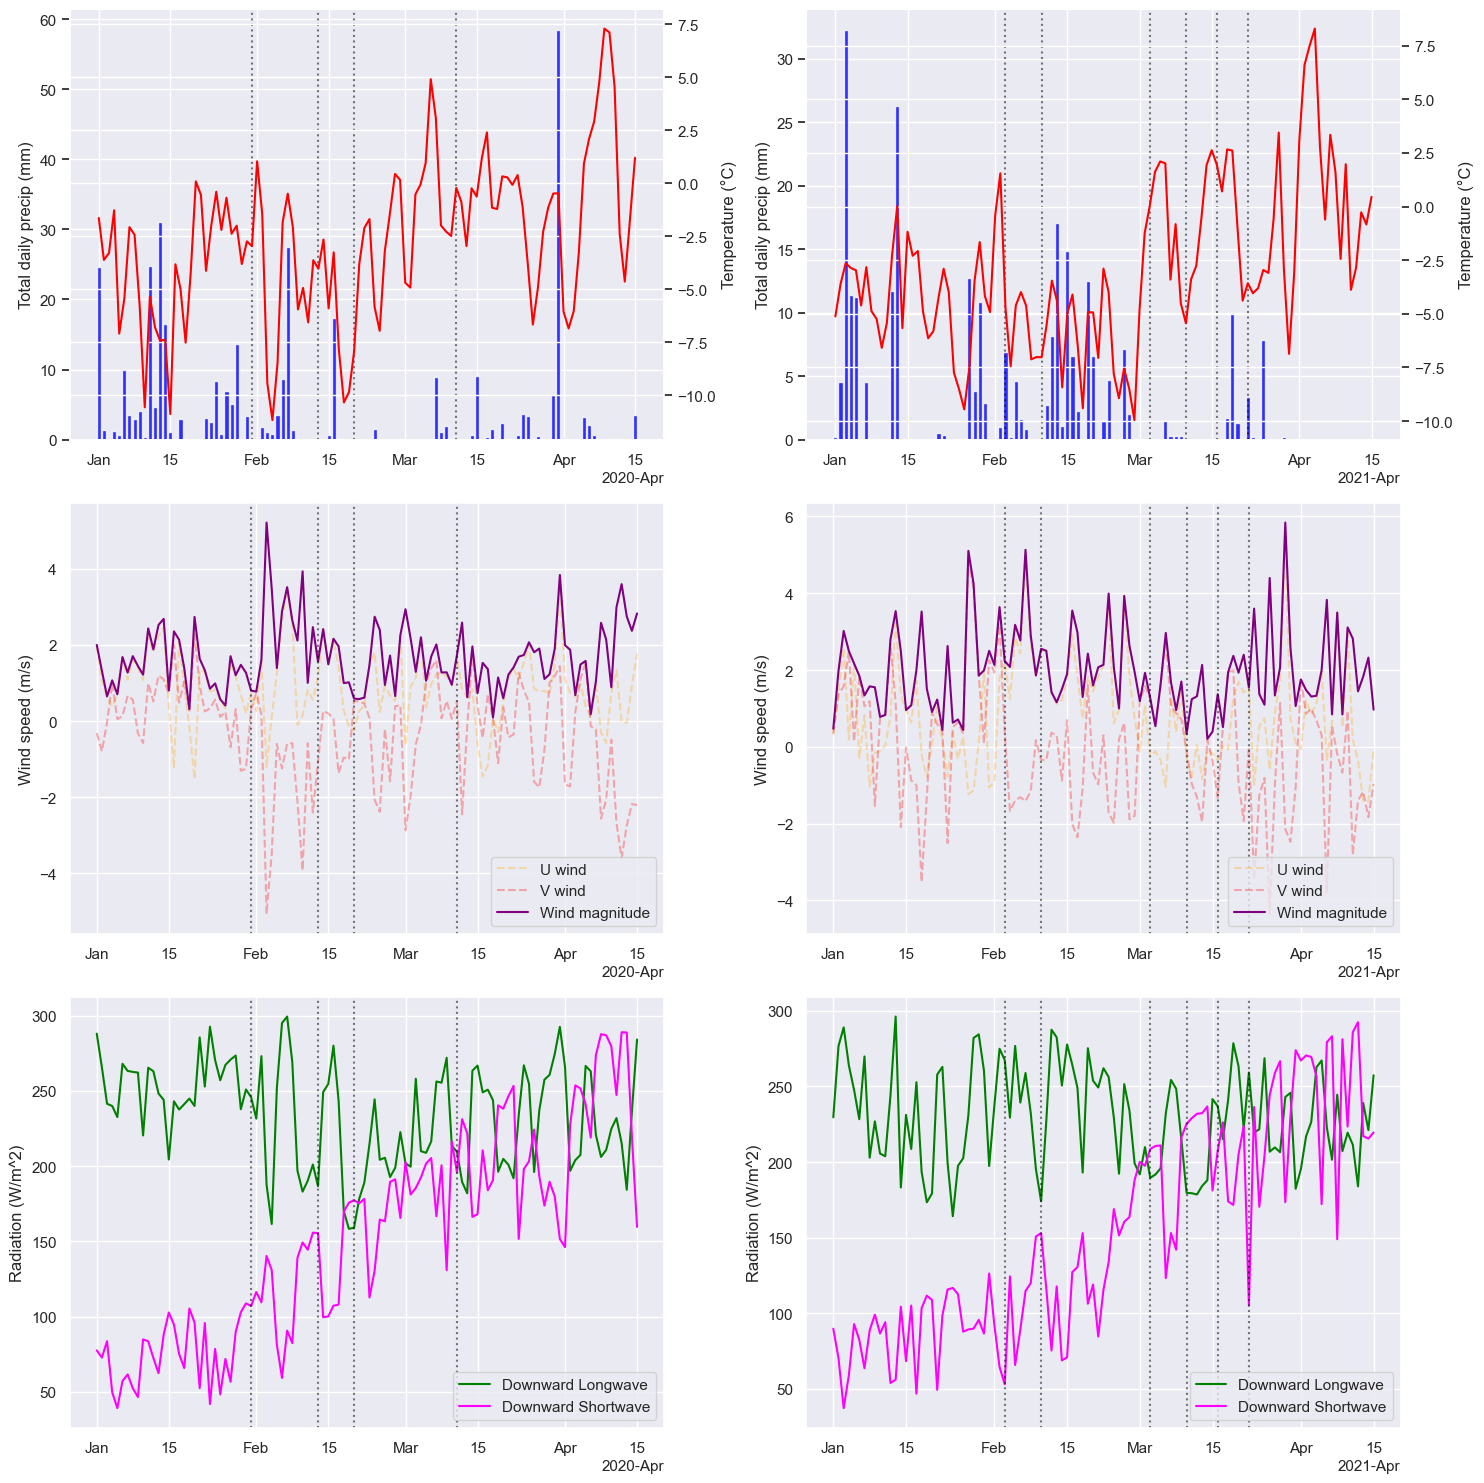

In [123]:
# plot full time series
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
plot_pairs = [('daily_precip', 'tmp_degC'),
            #   ('tmp_degC', 'SPFH_2maboveground'),
              ('UGRD_10maboveground', 'VGRD_10maboveground'),
              ('DLWRF_surface', 'DSWRF_surface')]

sl2021 = slice(datetime(2021, 1, 1, 0), datetime(2021, 4, 15, 0))
sl2020 = slice(datetime(2020, 1, 1, 0), datetime(2020, 4, 15, 0))
year1 = ds_daily.sel(time=sl2020)
year2 = ds_daily.sel(time=sl2021)
year1dates = [date for date in mcs_dates if date.year == 2020]
year2dates = [date for date in mcs_dates if date.year == 2021]

for i, (var1, var2) in enumerate(plot_pairs):
    if var1 == 'UGRD_10maboveground':
        # do some extra smoothing
        for j, year in enumerate([year1, year2]):
            year[var1].plot(ax=axes[i, j], label='U wind', 
                            linestyle='--', color='orange', alpha=0.3)
            year[var2].plot(ax=axes[i, j], label='V wind', 
                            linestyle='--', color='red', alpha=0.3)
            # ax2 = axes[i].twinx()
            year['wind_mag'].plot(ax=axes[i, j], label='Wind magnitude', 
                                  linestyle='-', color='purple')
            axes[i, j].set_ylabel('Wind speed (m/s)')
            axes[i, j].set_xlabel('')
            axes[i, j].set_title('')
            axes[i, j].legend(loc='lower right')
            # plot vertical line for MCS 
            for date in year1dates if j == 0 else year2dates:
                axes[i, j].axvline(date, color='black', linestyle=':', alpha=0.5)
        # axes[i, j].legend(loc='upper right')
    elif var1 == 'daily_precip':
        for j, year in enumerate([year1, year2]):
            # bar plot 
            axes[i, j].bar(year.time, year[var1], 
                    label='Daily Precip', color='blue', alpha=0.8)
            ax2 = axes[i, j].twinx()
            # year[var1].plot.bar(ax=axes[i, j], label='Daily Precip', color='lightblue')
            year[var2].plot(ax=ax2, label='Temperature (°C)', color='red')
            ax2.set_ylabel('Temperature (°C)')
            ax2.set_title('')
            axes[i, j].set_ylabel('Total daily precip (mm)')
            # rotate x labels
            # plt.setp(axes[i, j].get_xticklabels(), rotation=30)
            axes[i, j].set_xlabel('')
            axes[i, j].set_title('')
            for date in year1dates if j == 0 else year2dates:
                axes[i, j].axvline(date, color='black', linestyle=':', alpha=0.5)
    elif var1 == 'DLWRF_surface':
        for j, year in enumerate([year1, year2]):
            year[var1].plot(ax=axes[i, j], label='Downward Longwave', color='green')
            # ax2=axes[i, j].twinx()
            year[var2].plot(ax=axes[i, j], label='Downward Shortwave', color='magenta')
            axes[i, j].set_ylabel('Radiation (W/m^2)')
            axes[i, j].set_xlabel('')
            axes[i, j].set_title('')
            axes[i, j].legend(loc='lower right')
            # ax2.set_title('')
            for date in year1dates if j == 0 else year2dates:
                axes[i, j].axvline(date, color='black', linestyle=':', alpha=0.5)
    elif var1 == 'tmp_degC':
        for j, year in enumerate([year1, year2]):
            year[var1].plot(ax=axes[i, j], label='Temperature (°C)', color='red')
            # ax2=axes[i, j].twinx()
            # year[var2].plot(ax=ax2, color='orange', alpha=0.5)
            # ax2.spines['right'].set_color('orange')
            # ax2.tick_params(axis='y', colors='orange')
            # ax2.set_title('')
            axes[i, j].set_ylabel('Temperature (°C)')
            axes[i, j].set_xlabel('')
            axes[i, j].set_title('')
            for date in year1dates if j == 0 else year2dates:
                axes[i, j].axvline(date, color='black', linestyle=':', alpha=0.5)

    # axes[i].set_title(f'{vars[0]} and {vars[1]} over time')

plt.tight_layout()
plt.show()